# Historical vs. Projected Sea Temperature and Salinity Analysis

**ERA5 reanalysis (2011–2021) vs. SSP245 climate projection (2079–2089)**

This notebook compares a historical baseline (ERA5) against a moderate-emissions future climate projection (SSP245, CMIP6) at a single grid point in the Mediterranean Sea, for two variables: sea (potential) temperature and salinity.

**Workflow:**
1. Load and inspect the raw monthly time series for both periods.
2. Compute descriptive statistics and monthly climatologies (average annual cycle).
3. Compare historical vs. projected climatologies and seasonal (winter/summer) means.
4. Remove the climatology to isolate monthly anomalies, and fit linear trends to each.
5. Summarize everything in an exportable results table.
6. Examine how the temperature–salinity relationship changes between the two periods.

**Data:** `era5_temp.nc`, `era5_sal.nc`, `ssp245_temp_sal.nc` (NetCDF, not included in this repo — see README for source/access details). Variable names follow NEMO/CMIP conventions: `thetao` (potential temperature) and `so` (practical salinity).

---

## 1. Import Libraries

Standard libraries for loading NetCDF climate data (`xarray`), numerical operations (`numpy`), tabular output (`pandas`), and plotting (`matplotlib`).

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Load and Prepare the Data

Two datasets are used:

- **ERA5** (reanalysis, 2011–2021) — treated as the historical baseline.
- **SSP245** (climate projection, 2079–2089) — a moderate-emissions future scenario from CMIP6.

Each dataset provides monthly sea temperature (`thetao`) and salinity (`so`) at a single grid point/depth level. `.squeeze()` drops the singleton spatial/depth dimensions to leave a clean 1-D time series for each variable.

In [4]:
era5_temp = xr.open_dataset("era5_temp.nc")
era5_sal = xr.open_dataset("era5_sal.nc")
ssp245_temp_sal = xr.open_dataset("ssp245_temp_sal.nc")

In [5]:
era5_temp_series = era5_temp.thetao.squeeze()
era5_sal_series = era5_sal.so.squeeze()
ssp245_temp_series = ssp245_temp_sal.thetao.squeeze()
ssp245_sal_series = ssp245_temp_sal.so.squeeze()

## 3. Inspect the Data

Print the four extracted `xarray.DataArray` objects to confirm dimensions, coordinates, and units are as expected before doing any calculations.

In [7]:
print(era5_temp_series)
print(era5_sal_series)
print(ssp245_temp_series)
print(ssp245_sal_series)

<xarray.DataArray 'thetao' (time_counter: 132)> Size: 528B
[132 values with dtype=float32]
Coordinates:
  * time_counter  (time_counter) object 1kB 2011-01-16 12:00:00 ... 2021-12-1...
    X             float64 8B 0.0
    Y             float64 8B 0.0
Attributes:
    long_name:     Bathymetry
    units:         meters
    cell_methods:  time_counter: mean
<xarray.DataArray 'so' (time_counter: 132)> Size: 528B
[132 values with dtype=float32]
Coordinates:
  * time_counter  (time_counter) object 1kB 2011-01-16 12:00:00 ... 2021-12-1...
    X             float64 8B 0.0
    Y             float64 8B 0.0
Attributes:
    long_name:     Bathymetry
    units:         meters
    cell_methods:  time_counter: mean
<xarray.DataArray 'thetao' (time_counter: 132)> Size: 528B
[132 values with dtype=float32]
Coordinates:
  * time_counter  (time_counter) object 1kB 2079-01-16 12:00:00 ... 2089-12-1...
    lon           float64 8B 0.0
    lat           float64 8B 0.0
    deptht        float32 4B 0.5056
Att

## 4. Descriptive Statistics

Baseline mean, standard deviation, minimum, and maximum for each series, computed independently for the historical and projected periods.

In [9]:
print("ERA5 Temperature Statistics")
print(f"Mean: {era5_temp_series.mean().item():.1f} °C")
print(f"Standard deviation: {era5_temp_series.std().item():.2f} °C")
print(f"Minimum: {era5_temp_series.min().item():.1f} °C")
print(f"Maximum: {era5_temp_series.max().item():.1f} °C")

print()

print("ERA5 Salinity Statistics")
print(f"Mean: {era5_sal_series.mean().item():.2f} PSU")
print(f"Standard deviation: {era5_sal_series.std().item():.2f} PSU")
print(f"Minimum: {era5_sal_series.min().item():.2f} PSU")
print(f"Maximum: {era5_sal_series.max().item():.2f} PSU")

print()

print("SSP245 Temperature Statistics")
print(f"Mean: {ssp245_temp_series.mean().item():.1f} °C")
print(f"Standard deviation: {ssp245_temp_series.std().item():.2f} °C")
print(f"Minimum: {ssp245_temp_series.min().item():.1f} °C")
print(f"Maximum: {ssp245_temp_series.max().item():.1f} °C")

print()

print("SSP245 Salinity Statistics")
print(f"Mean: {ssp245_sal_series.mean().item():.2f} PSU")
print(f"Standard deviation: {ssp245_sal_series.std().item():.2f} PSU")
print(f"Minimum: {ssp245_sal_series.min().item():.2f} PSU")
print(f"Maximum: {ssp245_sal_series.max().item():.2f} PSU")

ERA5 Temperature Statistics
Mean: 20.5 °C
Standard deviation: 4.13 °C
Minimum: 14.8 °C
Maximum: 27.4 °C

ERA5 Salinity Statistics
Mean: 38.23 PSU
Standard deviation: 0.12 PSU
Minimum: 38.01 PSU
Maximum: 38.48 PSU

SSP245 Temperature Statistics
Mean: 23.7 °C
Standard deviation: 4.36 °C
Minimum: 16.2 °C
Maximum: 30.9 °C

SSP245 Salinity Statistics
Mean: 38.33 PSU
Standard deviation: 0.26 PSU
Minimum: 37.96 PSU
Maximum: 38.81 PSU


## 5. Original Monthly Time Series

Plot the raw monthly temperature and salinity series for both periods to visually inspect the seasonal cycle and any obvious trend before further processing.

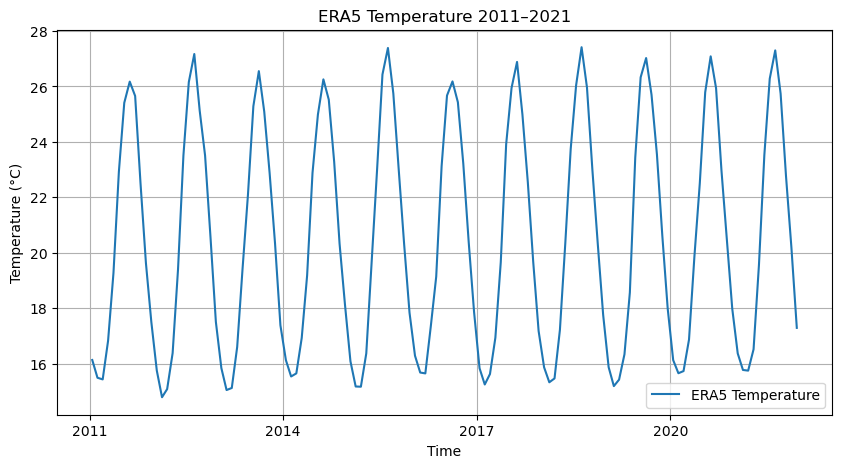

In [11]:
plt.figure(figsize=(10, 5))

era5_temp_series.plot(
    x="time_counter",
    label="ERA5 Temperature"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("ERA5 Temperature 2011–2021")
plt.legend()
plt.grid(True)
plt.savefig("era5_temperature.png", dpi=300, bbox_inches="tight")
plt.show()

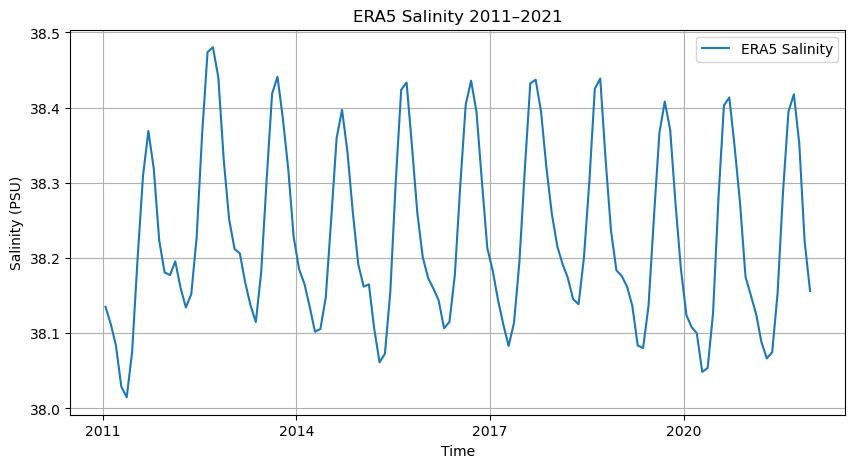

In [12]:
plt.figure(figsize=(10, 5))

era5_sal_series.plot(
    x="time_counter",
    label="ERA5 Salinity"
)

plt.xlabel("Time")
plt.ylabel("Salinity (PSU)")
plt.title("ERA5 Salinity 2011–2021")
plt.legend()
plt.grid(True)
plt.savefig("era5_salinity.png", dpi=300, bbox_inches="tight")
plt.show()

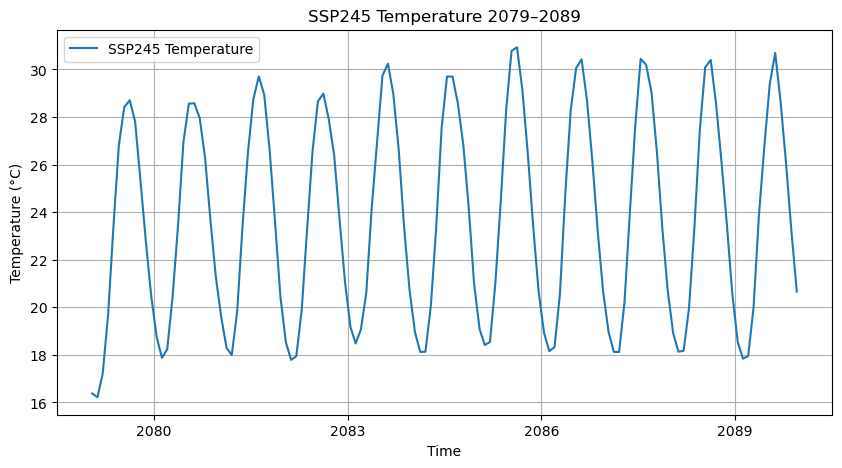

In [13]:
plt.figure(figsize=(10, 5))

ssp245_temp_series.plot(
    x="time_counter",
    label="SSP245 Temperature"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("SSP245 Temperature 2079–2089")
plt.legend()
plt.grid(True)
plt.savefig("ssp245_temperature.png", dpi=300, bbox_inches="tight")
plt.show()

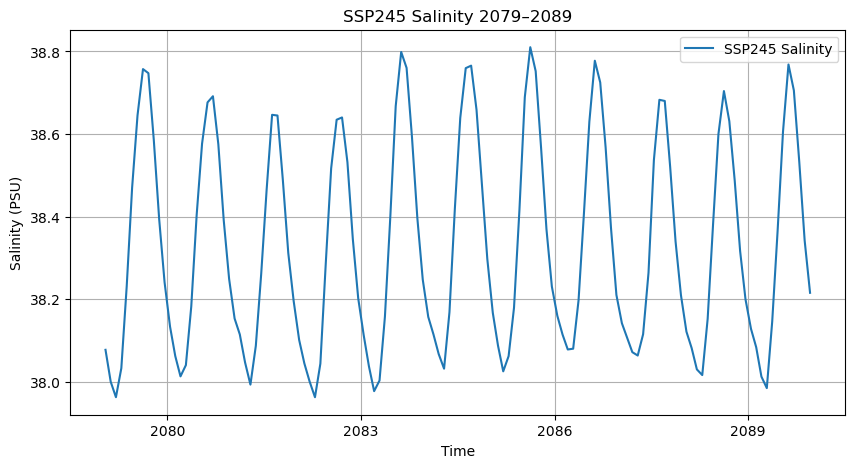

In [14]:
plt.figure(figsize=(10, 5))

ssp245_sal_series.plot(
    x="time_counter",
    label="SSP245 Salinity"
)

plt.xlabel("Time")
plt.ylabel("Salinity (PSU)")
plt.title("SSP245 Salinity 2079–2089")
plt.legend()
plt.grid(True)
plt.savefig("ssp245_salinity.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Monthly Climatologies

For each series, group by calendar month and average across all years in the period. This gives the mean annual cycle (climatology) for temperature and salinity, independently for ERA5 and SSP245.

In [16]:
era5_temp_climatology = era5_temp_series.groupby(
    "time_counter.month"
).mean()

In [17]:
print(era5_temp_climatology)
print()
print(era5_temp_climatology.values)

<xarray.DataArray 'thetao' (month: 12)> Size: 48B
array([16.024656 , 15.353619 , 15.4612465, 16.756233 , 19.462824 ,
       23.149315 , 25.847649 , 26.857176 , 25.53606  , 23.017826 ,
       20.259684 , 17.673967 ], dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    X        float64 8B 0.0
    Y        float64 8B 0.0
Attributes:
    long_name:     Bathymetry
    units:         meters
    cell_methods:  time_counter: mean

[16.024656  15.353619  15.4612465 16.756233  19.462824  23.149315
 25.847649  26.857176  25.53606   23.017826  20.259684  17.673967 ]


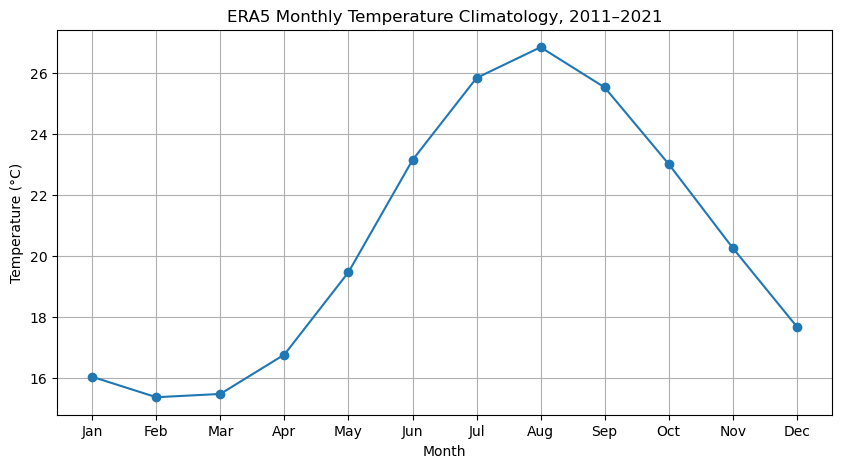

In [18]:
plt.figure(figsize=(10, 5))

era5_temp_climatology.plot(
    x="month",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("ERA5 Monthly Temperature Climatology, 2011–2021")

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.grid(True)

plt.savefig(
    "era5_temperature_climatology.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
era5_sal_climatology = era5_sal_series.groupby(
    "time_counter.month"
).mean()

In [20]:
print(era5_sal_climatology)
print()
print(era5_sal_climatology.values)


<xarray.DataArray 'so' (month: 12)> Size: 48B
array([38.172024, 38.157833, 38.1283  , 38.090717, 38.094254, 38.161552,
       38.28643 , 38.400906, 38.424717, 38.36572 , 38.274197, 38.202286],
      dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    X        float64 8B 0.0
    Y        float64 8B 0.0
Attributes:
    long_name:     Bathymetry
    units:         meters
    cell_methods:  time_counter: mean

[38.172024 38.157833 38.1283   38.090717 38.094254 38.161552 38.28643
 38.400906 38.424717 38.36572  38.274197 38.202286]


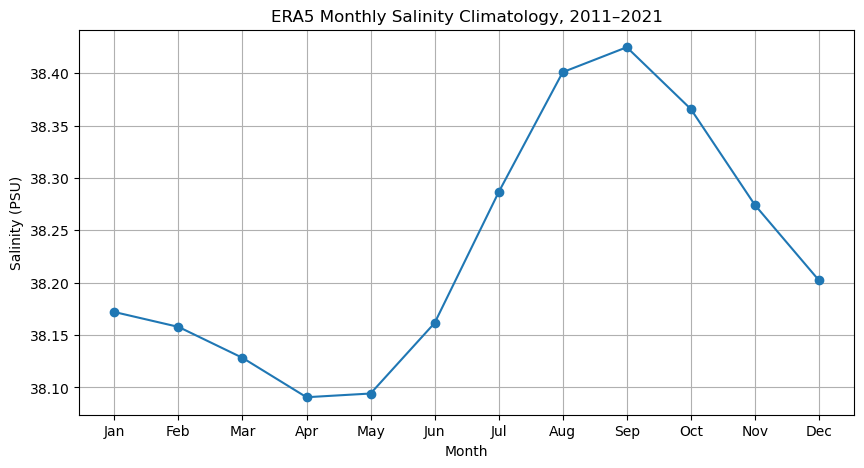

In [21]:
plt.figure(figsize=(10, 5))

era5_sal_climatology.plot(
    x="month",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Salinity (PSU)")
plt.title("ERA5 Monthly Salinity Climatology, 2011–2021")

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.grid(True)

plt.savefig(
    "era5_salinity_climatology.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
ssp245_temp_climatology = ssp245_temp_series.groupby(
    "time_counter.month"
).mean()

In [23]:
print(ssp245_temp_climatology)
print()
print(ssp245_temp_climatology.values)

<xarray.DataArray 'thetao' (month: 12)> Size: 48B
array([18.701897, 17.950775, 18.15525 , 20.20453 , 23.780525, 27.250122,
       29.509357, 29.872175, 28.561737, 26.307573, 23.44339 , 20.750427],
      dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    lon      float64 8B 0.0
    lat      float64 8B 0.0
    deptht   float32 4B 0.5056
Attributes:
    standard_name:       sea_water_potential_temperature
    long_name:           sea_water_potential_temperature
    units:               degC
    online_operation:    average
    interval_operation:  360 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 360 s)

[18.701897 17.950775 18.15525  20.20453  23.780525 27.250122 29.509357
 29.872175 28.561737 26.307573 23.44339  20.750427]


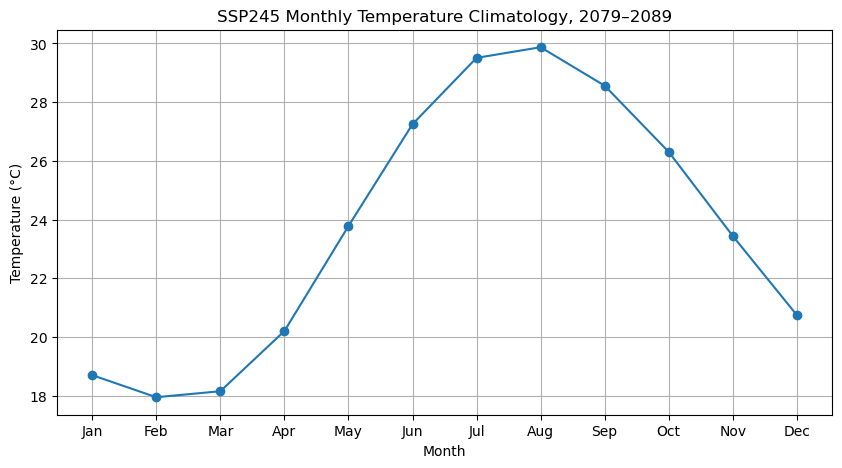

In [24]:
plt.figure(figsize=(10, 5))

ssp245_temp_climatology.plot(
    x="month",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("SSP245 Monthly Temperature Climatology, 2079–2089")

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.grid(True)

plt.savefig(
    "ssp245_temperature_climatology.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
ssp245_sal_climatology = ssp245_sal_series.groupby(
    "time_counter.month"
).mean()

In [26]:
print(ssp245_sal_climatology)
print()
print(ssp245_sal_climatology.values)

<xarray.DataArray 'so' (month: 12)> Size: 48B
array([38.131954, 38.076817, 38.02578 , 38.024353, 38.150913, 38.370308,
       38.597263, 38.728786, 38.70395 , 38.555096, 38.36862 , 38.226955],
      dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    lon      float64 8B 0.0
    lat      float64 8B 0.0
    deptht   float32 4B 0.5056
Attributes:
    standard_name:       sea_water_practical_salinity
    long_name:           sea_water_salinity
    units:               1e-3
    online_operation:    average
    interval_operation:  360 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 360 s)

[38.131954 38.076817 38.02578  38.024353 38.150913 38.370308 38.597263
 38.728786 38.70395  38.555096 38.36862  38.226955]


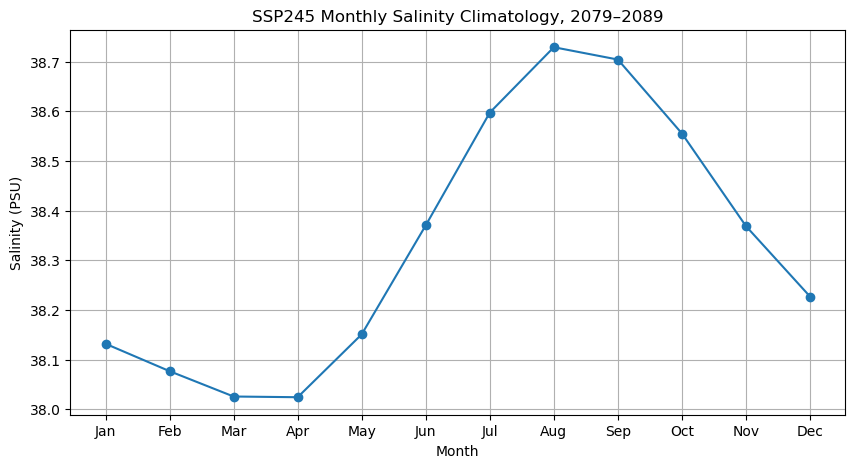

In [27]:
plt.figure(figsize=(10, 5))

ssp245_sal_climatology.plot(
    x="month",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Salinity (PSU)")
plt.title("SSP245 Monthly Salinity Climatology, 2079–2089")

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.grid(True)

plt.savefig(
    "ssp245_salinity_climatology.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Historical and Projected Climatology Comparison

Overlay the ERA5 and SSP245 climatologies on the same axes to compare the shape and magnitude of the seasonal cycle between the historical and projected periods.

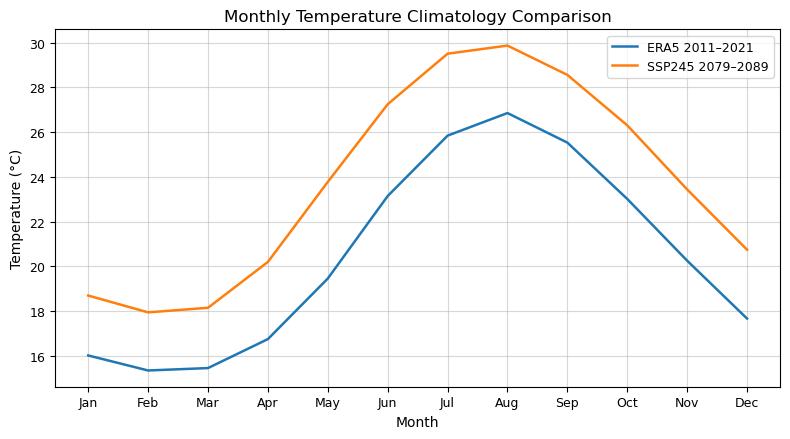

In [29]:
plt.figure(figsize=(8, 4.5))

era5_temp_climatology.plot(
    label="ERA5 2011–2021",
    linewidth=1.8
)

ssp245_temp_climatology.plot(
    label="SSP245 2079–2089",
    linewidth=1.8
)

plt.title("Monthly Temperature Climatology Comparison", fontsize=12)
plt.xlabel("Month", fontsize=10)
plt.ylabel("Temperature (°C)", fontsize=10)

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    fontsize=9
)

plt.yticks(fontsize=9)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.5)

plt.tight_layout()

plt.savefig(
    "era5ssp245_temp_climcomparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

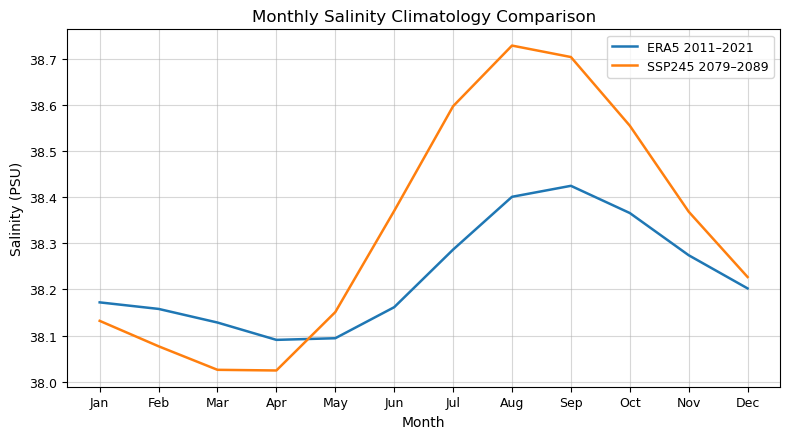

In [30]:
plt.figure(figsize=(8, 4.5))

era5_sal_climatology.plot(
    label="ERA5 2011–2021",
    linewidth=1.8
)

ssp245_sal_climatology.plot(
    label="SSP245 2079–2089",
    linewidth=1.8
)

plt.title("Monthly Salinity Climatology Comparison", fontsize=12)
plt.xlabel("Month", fontsize=10)
plt.ylabel("Salinity (PSU)", fontsize=10)

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    fontsize=9
)

plt.yticks(fontsize=9)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.5)

plt.tight_layout()

plt.savefig(
    "era5ssp245_sal_climcomparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Seasonal Mean Comparison

Aggregate the monthly climatology into winter (DJF) and summer (JJA) means, for both variables and both periods, to summarize the seasonal contrast in a single comparable number.

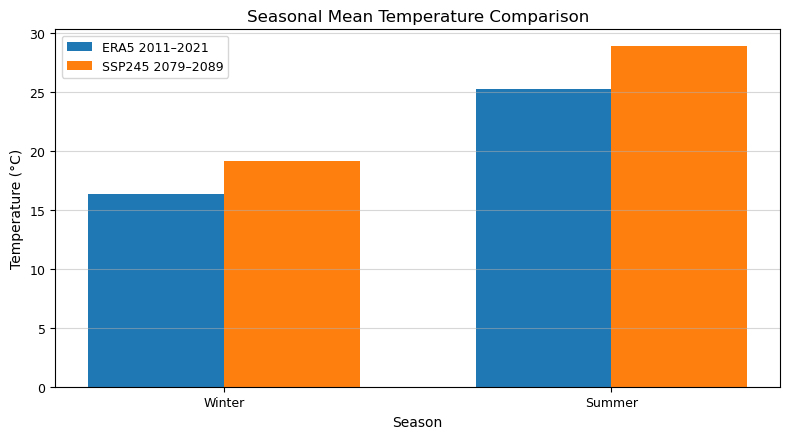

In [32]:
# Seasonal means
era5_temp_winter = era5_temp_climatology.sel(
    month=[12, 1, 2]
).mean().item()

era5_temp_summer = era5_temp_climatology.sel(
    month=[6, 7, 8]
).mean().item()

ssp245_temp_winter = ssp245_temp_climatology.sel(
    month=[12, 1, 2]
).mean().item()

ssp245_temp_summer = ssp245_temp_climatology.sel(
    month=[6, 7, 8]
).mean().item()


# Bar-chart data
seasons = ["Winter", "Summer"]
x = np.arange(len(seasons))
bar_width = 0.35

era5_values = [
    era5_temp_winter,
    era5_temp_summer
]

ssp245_values = [
    ssp245_temp_winter,
    ssp245_temp_summer
]


# Plot
plt.figure(figsize=(8, 4.5))

plt.bar(
    x - bar_width / 2,
    era5_values,
    width=bar_width,
    label="ERA5 2011–2021"
)

plt.bar(
    x + bar_width / 2,
    ssp245_values,
    width=bar_width,
    label="SSP245 2079–2089"
)

plt.title("Seasonal Mean Temperature Comparison", fontsize=12)
plt.xlabel("Season", fontsize=10)
plt.ylabel("Temperature (°C)", fontsize=10)

plt.xticks(x, seasons, fontsize=9)
plt.yticks(fontsize=9)

plt.legend(fontsize=9)
plt.grid(axis="y", alpha=0.5)

plt.tight_layout()

plt.savefig(
    "seasonal_temperature_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

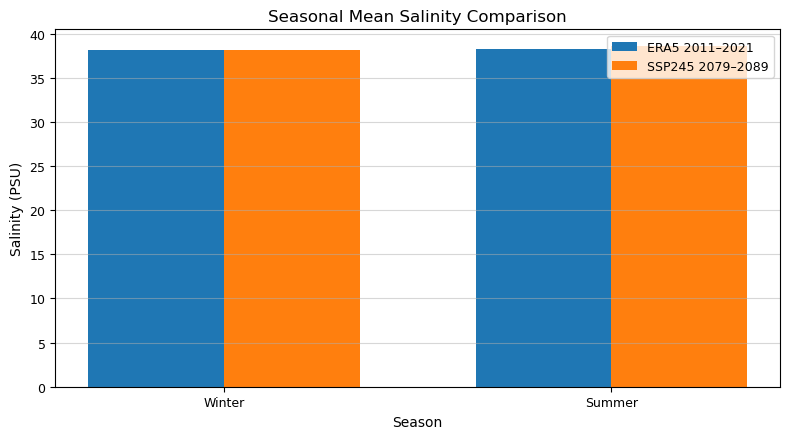

In [33]:
# Seasonal means
era5_sal_winter = era5_sal_climatology.sel(
    month=[12, 1, 2]
).mean().item()

era5_sal_summer = era5_sal_climatology.sel(
    month=[6, 7, 8]
).mean().item()

ssp245_sal_winter = ssp245_sal_climatology.sel(
    month=[12, 1, 2]
).mean().item()

ssp245_sal_summer = ssp245_sal_climatology.sel(
    month=[6, 7, 8]
).mean().item()


# Bar-chart data
seasons = ["Winter", "Summer"]
x = np.arange(len(seasons))
bar_width = 0.35

era5_values = [
    era5_sal_winter,
    era5_sal_summer
]

ssp245_values = [
    ssp245_sal_winter,
    ssp245_sal_summer
]


# Plot
plt.figure(figsize=(8, 4.5))

plt.bar(
    x - bar_width / 2,
    era5_values,
    width=bar_width,
    label="ERA5 2011–2021"
)

plt.bar(
    x + bar_width / 2,
    ssp245_values,
    width=bar_width,
    label="SSP245 2079–2089"
)

plt.title("Seasonal Mean Salinity Comparison", fontsize=12)
plt.xlabel("Season", fontsize=10)
plt.ylabel("Salinity (PSU)", fontsize=10)

plt.xticks(x, seasons, fontsize=9)
plt.yticks(fontsize=9)

plt.legend(fontsize=9)
plt.grid(axis="y", alpha=0.5)

plt.tight_layout()

plt.savefig(
    "seasonal_salinity_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Projected Monthly Climatological Changes

Subtract the ERA5 climatology from the SSP245 climatology, month by month, to get the projected change signal.

Computed results (2079–2089 minus 2011–2021):

- **Temperature:** +2.6 to +4.3 °C across the year, largest in boreal spring/early summer (Apr–Jun) and smallest in winter (Jan–Mar).
- **Salinity:** slightly *negative* in winter (down to −0.10 PSU, Jan–Mar) but *positive* in summer (up to +0.33 PSU, Jul–Aug) — i.e. the seasonal salinity cycle amplifies under SSP245 rather than shifting uniformly.

In [35]:
temp_climatology_change = ssp245_temp_climatology - era5_temp_climatology
print(temp_climatology_change)

<xarray.DataArray 'thetao' (month: 12)> Size: 48B
array([2.6772404, 2.5971565, 2.694004 , 3.4482975, 4.3177013, 4.100807 ,
       3.6617088, 3.0149994, 3.0256767, 3.2897472, 3.1837063, 3.07646  ],
      dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    lon      float64 8B 0.0
    lat      float64 8B 0.0
    deptht   float32 4B 0.5056
    X        float64 8B 0.0
    Y        float64 8B 0.0
Attributes:
    standard_name:       sea_water_potential_temperature
    online_operation:    average
    interval_operation:  360 s
    interval_write:      1 month


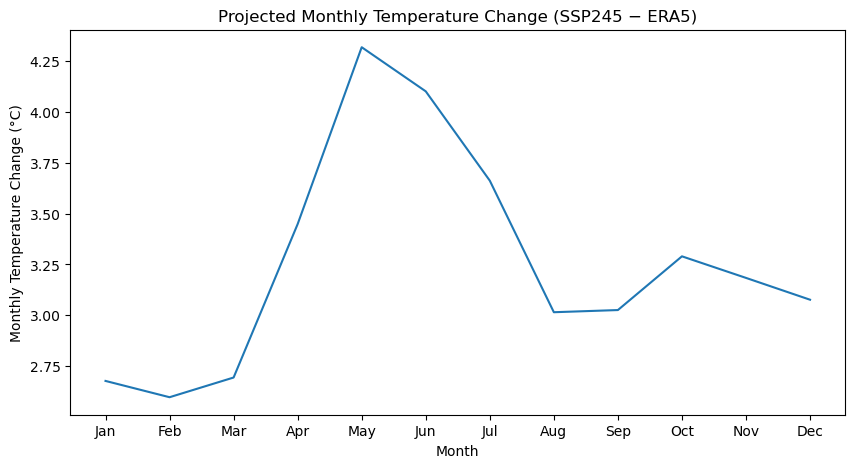

In [36]:
plt.figure(figsize=(10, 5))

temp_climatology_change.plot(
    x = "month",
   
)
plt.title("Projected Monthly Temperature Change (SSP245 − ERA5)")
plt.xlabel("Month")
plt.ylabel("Monthly Temperature Change (°C)")



plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.savefig(
    "monthly_temp_change.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [37]:
sal_climatology_change = ssp245_sal_climatology - era5_sal_climatology
print(sal_climatology_change)

<xarray.DataArray 'so' (month: 12)> Size: 48B
array([-0.04006958, -0.08101654, -0.10251999, -0.06636429,  0.0566597 ,
        0.2087555 ,  0.31083298,  0.32788086,  0.27923203,  0.18937683,
        0.0944252 ,  0.02466965], dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    lon      float64 8B 0.0
    lat      float64 8B 0.0
    deptht   float32 4B 0.5056
    X        float64 8B 0.0
    Y        float64 8B 0.0
Attributes:
    standard_name:       sea_water_practical_salinity
    online_operation:    average
    interval_operation:  360 s
    interval_write:      1 month


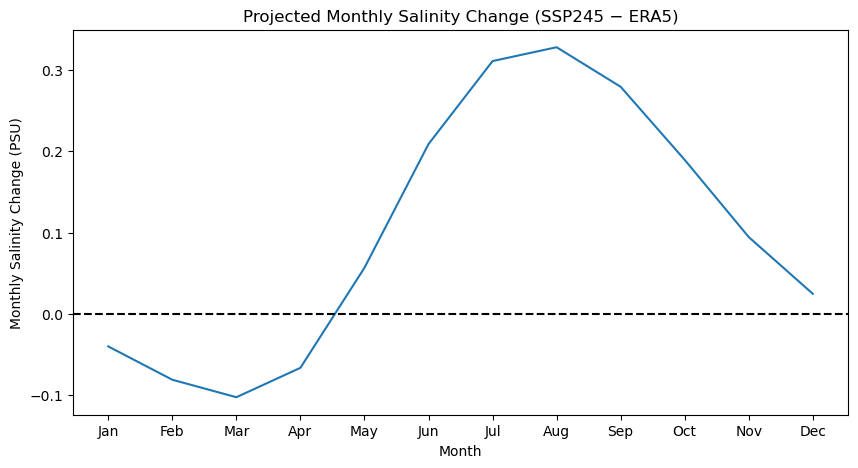

In [38]:
plt.figure(figsize=(10, 5))

sal_climatology_change.plot(
    x = "month",
   
)
plt.title("Projected Monthly Salinity Change (SSP245 − ERA5)")
plt.xlabel("Month")
plt.ylabel("Monthly Salinity Change (PSU)")

plt.axhline(0, color="black", linestyle="--")



plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.savefig(
    "monthly_sal_change.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 10. Calculate Monthly Anomalies

Remove the monthly climatology from each raw series (`groupby(...) - climatology`) to isolate the anomaly: the year-to-year variability left over once the average seasonal cycle is subtracted out. This is the standard way to isolate a long-term trend from a strongly seasonal signal.

In [40]:
era5_temp_anomaly = era5_temp_series.groupby("time_counter.month") - era5_temp_climatology
print(era5_temp_anomaly)

<xarray.DataArray 'thetao' (time_counter: 132)> Size: 528B
array([ 0.10546875,  0.13567924, -0.03187466,  0.0682106 , -0.1892643 ,
       -0.22921944, -0.4389286 , -0.6833477 ,  0.12052917, -0.5233269 ,
       -0.63300705, -0.16828346, -0.27674198, -0.56702805, -0.3811741 ,
       -0.37732887, -0.06260872,  0.35749626,  0.31017876,  0.31240654,
       -0.40820503,  0.48943138,  0.31332016, -0.1692276 , -0.18534946,
       -0.30799103, -0.3411522 , -0.15736961, -0.03260803, -1.0529594 ,
       -0.56147766, -0.3053341 , -0.4432888 , -0.14571953,  0.08087921,
       -0.29267883,  0.09906006,  0.18117714,  0.18574524,  0.17002487,
       -0.28255463, -0.266716  , -0.86214066, -0.6016884 , -0.01313782,
        0.26166534,  0.06599236,  0.45832253,  0.05920219, -0.17964172,
       -0.2953663 , -0.38944054,  0.20620918, -0.16261292,  0.5839653 ,
        0.53004074,  0.2077446 , -0.02121735,  0.05756378,  0.1632595 ,
        0.25956345,  0.32367706,  0.18472004,  0.597414  , -0.32481003,
     

In [41]:
era5_sal_anomaly = era5_sal_series.groupby("time_counter.month") - era5_sal_climatology
print(era5_sal_anomaly)

<xarray.DataArray 'so' (time_counter: 132)> Size: 528B
array([-0.03676605, -0.04527664, -0.04463959, -0.06195068, -0.07931137,
       -0.08654404, -0.08863449, -0.09186935, -0.05577087, -0.04708862,
       -0.05046844, -0.02135849,  0.00534821,  0.03774643,  0.03303146,
        0.04355621,  0.05772781,  0.06615448,  0.07700348,  0.07292557,
        0.05561829,  0.07426834,  0.05663681,  0.04912949,  0.03993225,
        0.04851913,  0.04030228,  0.04690552,  0.02066422,  0.0202446 ,
        0.01677322,  0.01755524,  0.01636887,  0.01968765,  0.04399872,
        0.02554703,  0.01285934,  0.00818253,  0.00769806,  0.01129532,
        0.01135635, -0.01385498, -0.03585052, -0.04122925, -0.02767181,
       -0.02433395, -0.01340866, -0.01023865, -0.01010513,  0.00717163,
       -0.02128601, -0.02933884, -0.02144241, -0.00659561,  0.01402664,
        0.02281189,  0.00877762, -0.01701736, -0.01461029, -0.00124359,
        0.00098801,  0.00134277,  0.01577759,  0.01597214,  0.02090454,
        0

In [42]:
ssp245_temp_anomaly = ssp245_temp_series.groupby("time_counter.month") - ssp245_temp_climatology
print(ssp245_temp_anomaly)

<xarray.DataArray 'thetao' (time_counter: 132)> Size: 528B
array([-2.3236752 , -1.7302608 , -0.9480572 , -0.53889084, -0.3461914 ,
       -0.4353714 , -1.0871925 , -1.1665173 , -0.75914955, -1.0087929 ,
       -0.7086258 , -0.31220245,  0.0224781 , -0.07671165,  0.08942795,
        0.2594509 , -0.3442688 , -0.31591415, -0.94610023, -1.2910995 ,
       -0.6026592 , -0.02662277,  0.19701004,  0.51384926,  0.86055565,
        0.33984566, -0.16074371, -0.37975693, -0.33750343, -0.72857666,
       -0.7486725 , -0.16271019,  0.3727665 ,  0.30956078,  0.16041756,
       -0.30712318, -0.1769085 , -0.15867043, -0.20656013, -0.3072319 ,
       -0.48234558, -0.69534683, -0.84931564, -0.88384056, -0.6611004 ,
        0.07865143,  0.24742126,  0.33445358,  0.47590256,  0.53027916,
        0.91116714,  0.40044594,  0.37430763, -0.29582214,  0.2298336 ,
        0.3747387 ,  0.40524292,  0.3151741 , -0.07875061, -0.01408768,
        0.24475479,  0.17379951, -0.02331924, -0.15307617, -0.41869164,
     

In [43]:
ssp245_sal_anomaly = ssp245_sal_series.groupby("time_counter.month") - ssp245_sal_climatology
print(ssp245_sal_anomaly)

<xarray.DataArray 'so' (time_counter: 132)> Size: 528B
array([-0.05477142, -0.07711792, -0.06337357,  0.00830078,  0.08076859,
        0.09975433,  0.04778671,  0.02848816,  0.0434761 ,  0.03091049,
        0.02512741,  0.01395035,  0.00125122, -0.01477051, -0.01290512,
        0.0157547 ,  0.03156281,  0.03367996, -0.02070999, -0.0521431 ,
       -0.01242447,  0.02014542,  0.02257919,  0.02199173,  0.02106857,
        0.03760147,  0.02116776, -0.0314827 , -0.06407928, -0.10874557,
       -0.13303375, -0.08228302, -0.05913544, -0.06750107, -0.05672836,
       -0.0316124 , -0.0308075 , -0.03258514, -0.02517319, -0.06201553,
       -0.10716248, -0.08401871, -0.08052444, -0.0941925 , -0.06378555,
       -0.02343369, -0.02293396, -0.02505112, -0.01932907, -0.03936386,
       -0.04871368, -0.02152634,  0.00649643,  0.02904892,  0.07030106,
        0.07000732,  0.05626678,  0.03734589,  0.02703857,  0.02027512,
        0.02504349,  0.03776932,  0.04128265,  0.00712967,  0.0175209 ,
        0

## 11. Plot Monthly Anomalies

Plot the anomaly time series for all four combinations of variable and period, with a zero reference line, to visually check for drift over time.

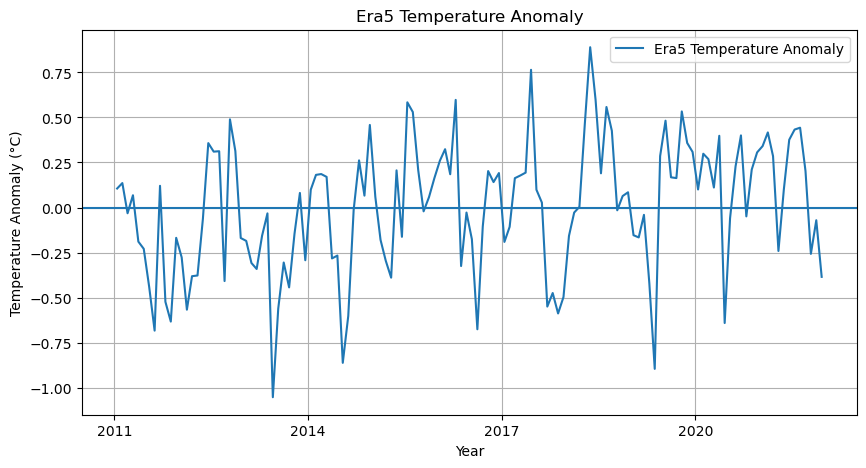

In [45]:
plt.figure(figsize=(10, 5))

era5_temp_anomaly.plot(
    x = "time_counter",
    label = "Era5 Temperature Anomaly" 
)
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.axhline(y=0)
plt.title("Era5 Temperature Anomaly")
plt.grid(True)
plt.legend()

plt.savefig(
    "era5_temp_anomaly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

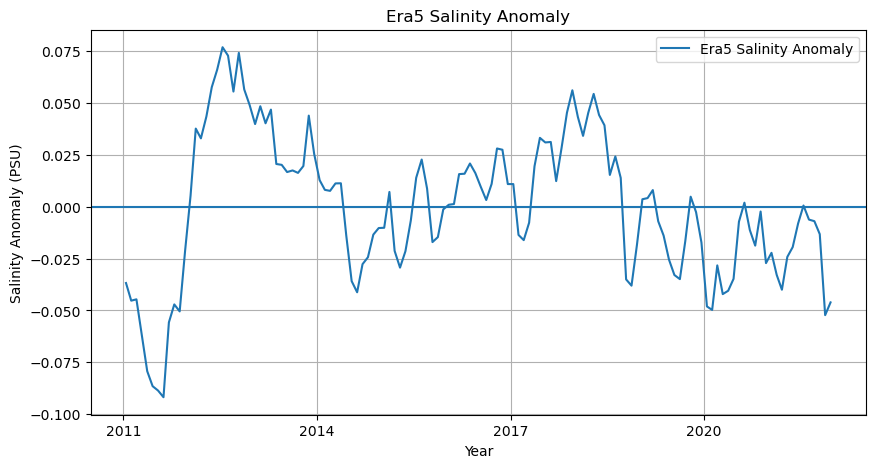

In [46]:
plt.figure(figsize=(10, 5))

era5_sal_anomaly.plot(
    x = "time_counter",
    label = "Era5 Salinity Anomaly" 
)
plt.xlabel("Year")
plt.ylabel("Salinity Anomaly (PSU)")
plt.axhline(y=0)
plt.title("Era5 Salinity Anomaly")
plt.grid(True)
plt.legend()

plt.savefig(
    "era5_sal_anomaly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

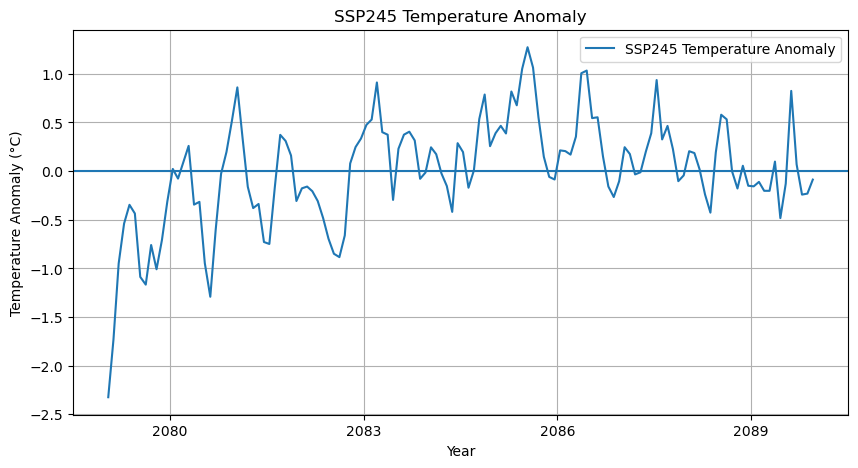

In [47]:
plt.figure(figsize=(10, 5))

ssp245_temp_anomaly.plot(
    x = "time_counter",
    label = "SSP245 Temperature Anomaly" 
)
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.axhline(y=0)
plt.title("SSP245 Temperature Anomaly")
plt.grid(True)
plt.legend()

plt.savefig(
    "ssp245_temp_anomaly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

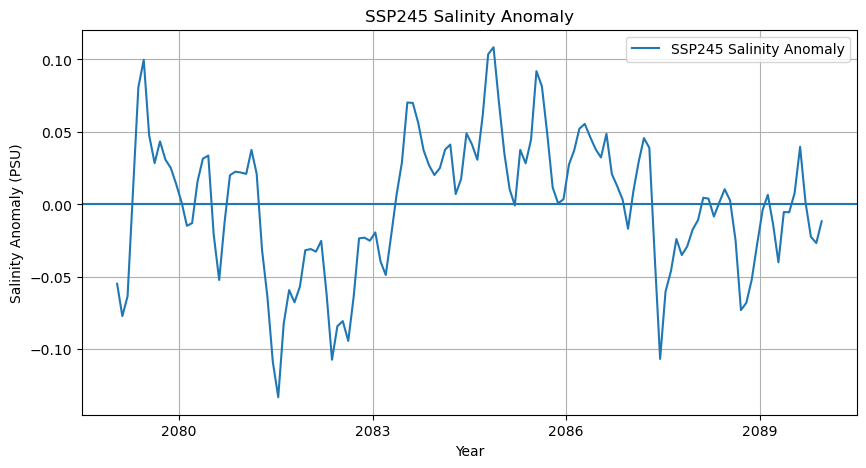

In [48]:
plt.figure(figsize=(10, 5))

ssp245_sal_anomaly.plot(
    x = "time_counter",
    label = "SSP245 Salinity Anomaly" 
)
plt.xlabel("Year")
plt.ylabel("Salinity Anomaly (PSU)")
plt.axhline(y=0)
plt.title("SSP245 Salinity Anomaly")
plt.grid(True)
plt.legend()

plt.savefig(
    "ssp245_sal_anomaly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12. Individual Linear Trends

Fit a first-degree polynomial (`np.polyfit`, degree 1) to each anomaly series to estimate its linear trend. The monthly slope is multiplied by 12 to express the trend as change per year.

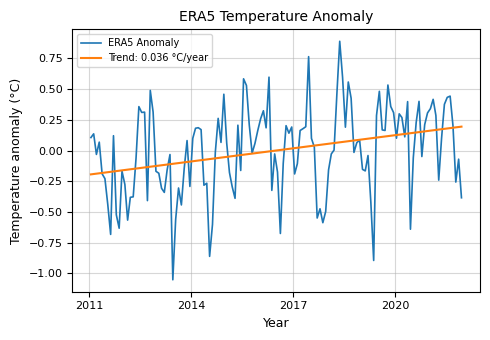

In [50]:
plt.figure(figsize=(5, 3.5))

x = np.arange(len(era5_temp_anomaly))

a, b = np.polyfit(
    x,
    era5_temp_anomaly,
    1
)

trendline = a * x + b
annual_trend = a * 12

era5_temp_anomaly.plot(
    x="time_counter",
    label="ERA5 Anomaly",
    linewidth=1.2
)

plt.plot(
    era5_temp_anomaly["time_counter"],
    trendline,
    label=f"Trend: {annual_trend:.3f} °C/year",
    linewidth=1.5
)

plt.xlabel("Year", fontsize=9)
plt.ylabel("Temperature anomaly (°C)", fontsize=9)
plt.title("ERA5 Temperature Anomaly", fontsize=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.legend(
    fontsize=7,
    loc="upper left",
    frameon=True
)

plt.grid(True, alpha=0.5)

plt.tight_layout()

plt.savefig(
    "era5_temp_anomaly_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

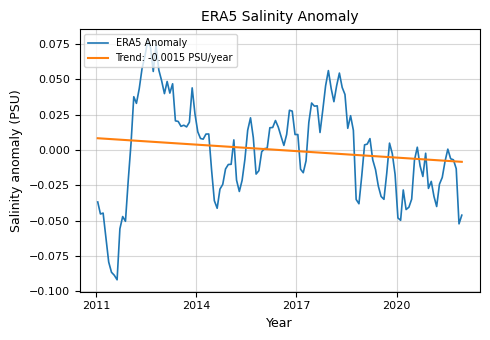

In [51]:
plt.figure(figsize=(5, 3.5))

x = np.arange(len(era5_sal_anomaly))

a, b = np.polyfit(
    x,
    era5_sal_anomaly,
    1
)

trendline = a * x + b
annual_trend = a * 12

era5_sal_anomaly.plot(
    x="time_counter",
    label="ERA5 Anomaly",
    linewidth=1.2
)

plt.plot(
    era5_sal_anomaly["time_counter"],
    trendline,
    label=f"Trend: {annual_trend:.4f} PSU/year",
    linewidth=1.5
)

plt.xlabel("Year", fontsize=9)
plt.ylabel("Salinity anomaly (PSU)", fontsize=9)
plt.title("ERA5 Salinity Anomaly", fontsize=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.legend(
    fontsize=7,
    loc="upper left",
    frameon=True
)

plt.grid(True, alpha=0.5)

plt.tight_layout()

plt.savefig(
    "era5_sal_anomaly_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

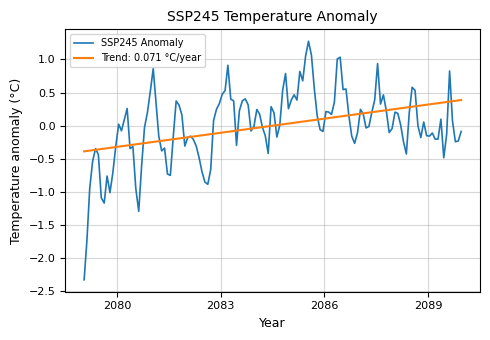

In [52]:
plt.figure(figsize=(5, 3.5))

x = np.arange(len(ssp245_temp_anomaly))

a, b = np.polyfit(
    x,
    ssp245_temp_anomaly,
    1
)

trendline = a * x + b
annual_trend = a * 12

ssp245_temp_anomaly.plot(
    x="time_counter",
    label="SSP245 Anomaly",
    linewidth=1.2
)

plt.plot(
    ssp245_temp_anomaly["time_counter"],
    trendline,
    label=f"Trend: {annual_trend:.3f} °C/year",
    linewidth=1.5
)

plt.xlabel("Year", fontsize=9)
plt.ylabel("Temperature anomaly (°C)", fontsize=9)
plt.title("SSP245 Temperature Anomaly", fontsize=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.legend(
    fontsize=7,
    loc="upper left",
    frameon=True
)

plt.grid(True, alpha=0.5)

plt.tight_layout()

plt.savefig(
    "ssp245_temp_anomaly_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

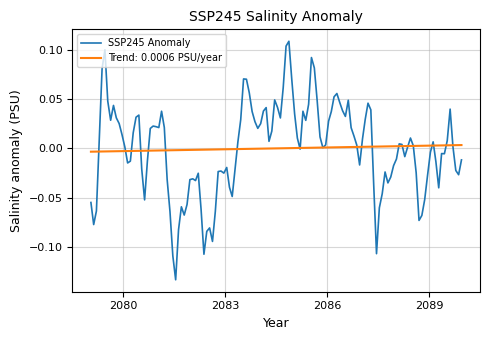

In [53]:
plt.figure(figsize=(5, 3.5))

x = np.arange(len(ssp245_sal_anomaly))

a, b = np.polyfit(
    x,
    ssp245_sal_anomaly,
    1
)

trendline = a * x + b
annual_trend = a * 12

ssp245_sal_anomaly.plot(
    x="time_counter",
    label="SSP245 Anomaly",
    linewidth=1.2
)

plt.plot(
    ssp245_sal_anomaly["time_counter"],
    trendline,
    label=f"Trend: {annual_trend:.4f} PSU/year",
    linewidth=1.5
)

plt.xlabel("Year", fontsize=9)
plt.ylabel("Salinity anomaly (PSU)", fontsize=9)
plt.title("SSP245 Salinity Anomaly", fontsize=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.legend(
    fontsize=7,
    loc="upper left",
    frameon=True
)

plt.grid(True, alpha=0.5)

plt.tight_layout()

plt.savefig(
    "ssp245_sal_anomaly_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13. Historical and Projected Trend Comparison

Plot the ERA5 and SSP245 trend lines side by side (same y-axis scale within each variable) so the historical and projected drift rates can be compared visually.

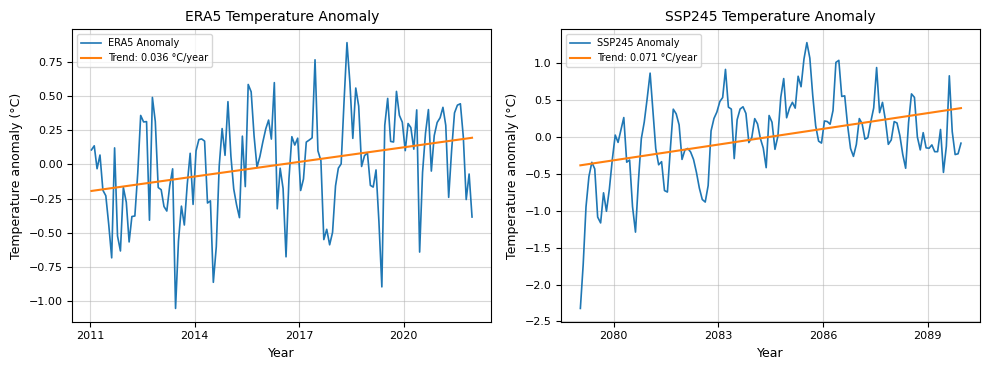

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# ERA5
x1 = np.arange(len(era5_temp_anomaly))
a1, b1 = np.polyfit(x1, era5_temp_anomaly, 1)
trendline1 = a1 * x1 + b1
annual_trend1 = a1 * 12

era5_temp_anomaly.plot(
    ax=axes[0],
    x="time_counter",
    label="ERA5 Anomaly",
    linewidth=1.2
)

axes[0].plot(
    era5_temp_anomaly["time_counter"],
    trendline1,
    label=f"Trend: {annual_trend1:.3f} °C/year",
    linewidth=1.5
)

axes[0].set_title("ERA5 Temperature Anomaly", fontsize=10)
axes[0].set_xlabel("Year", fontsize=9)
axes[0].set_ylabel("Temperature anomaly (°C)", fontsize=9)
axes[0].tick_params(labelsize=8)
axes[0].legend(fontsize=7, loc="upper left")
axes[0].grid(True, alpha=0.5)


# SSP245
x2 = np.arange(len(ssp245_temp_anomaly))
a2, b2 = np.polyfit(x2, ssp245_temp_anomaly, 1)
trendline2 = a2 * x2 + b2
annual_trend2 = a2 * 12

ssp245_temp_anomaly.plot(
    ax=axes[1],
    x="time_counter",
    label="SSP245 Anomaly",
    linewidth=1.2
)

axes[1].plot(
    ssp245_temp_anomaly["time_counter"],
    trendline2,
    label=f"Trend: {annual_trend2:.3f} °C/year",
    linewidth=1.5
)

axes[1].set_title("SSP245 Temperature Anomaly", fontsize=10)
axes[1].set_xlabel("Year", fontsize=9)
axes[1].set_ylabel("Temperature anomaly (°C)", fontsize=9)
axes[1].tick_params(labelsize=8)
axes[1].legend(fontsize=7, loc="upper left")
axes[1].grid(True, alpha=0.5)

plt.tight_layout()

plt.savefig(
    "temperature_anomaly_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

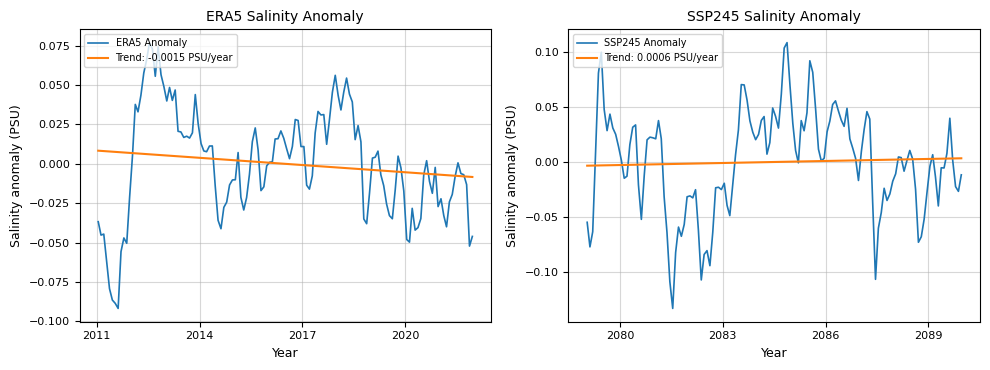

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# ERA5
x1 = np.arange(len(era5_sal_anomaly))
a1, b1 = np.polyfit(x1, era5_sal_anomaly, 1)
trendline1 = a1 * x1 + b1
annual_trend1 = a1 * 12

era5_sal_anomaly.plot(
    ax=axes[0],
    x="time_counter",
    label="ERA5 Anomaly",
    linewidth=1.2
)

axes[0].plot(
    era5_sal_anomaly["time_counter"],
    trendline1,
    label=f"Trend: {annual_trend1:.4f} PSU/year",
    linewidth=1.5
)

axes[0].set_title("ERA5 Salinity Anomaly", fontsize=10)
axes[0].set_xlabel("Year", fontsize=9)
axes[0].set_ylabel("Salinity anomaly (PSU)", fontsize=9)
axes[0].tick_params(labelsize=8)
axes[0].legend(fontsize=7, loc="upper left")
axes[0].grid(True, alpha=0.5)


# SSP245
x2 = np.arange(len(ssp245_sal_anomaly))
a2, b2 = np.polyfit(x2, ssp245_sal_anomaly, 1)
trendline2 = a2 * x2 + b2
annual_trend2 = a2 * 12

ssp245_sal_anomaly.plot(
    ax=axes[1],
    x="time_counter",
    label="SSP245 Anomaly",
    linewidth=1.2
)

axes[1].plot(
    ssp245_sal_anomaly["time_counter"],
    trendline2,
    label=f"Trend: {annual_trend2:.4f} PSU/year",
    linewidth=1.5
)

axes[1].set_title("SSP245 Salinity Anomaly", fontsize=10)
axes[1].set_xlabel("Year", fontsize=9)
axes[1].set_ylabel("Salinity anomaly (PSU)", fontsize=9)
axes[1].tick_params(labelsize=8)
axes[1].legend(fontsize=7, loc="upper left")
axes[1].grid(True, alpha=0.5)

plt.tight_layout()

plt.savefig(
    "salinity_anomaly_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14. Summary Statistics and Trend Results

Collect the descriptive statistics (Section 4) and the annual trend values (Section 12) into plain Python variables, ready to be assembled into the final results table.

In [58]:
# ERA5 temperature
era5_temp_mean = era5_temp_series.mean().item()
era5_temp_std = era5_temp_series.std().item()
era5_temp_min = era5_temp_series.min().item()
era5_temp_max = era5_temp_series.max().item()

era5_temp_x = np.arange(len(era5_temp_anomaly))

era5_temp_slope, era5_temp_intercept = np.polyfit(
    era5_temp_x,
    era5_temp_anomaly,
    1
)

era5_temp_annual_trend = era5_temp_slope * 12

# ERA5 salinity
era5_sal_mean = era5_sal_series.mean().item()
era5_sal_std = era5_sal_series.std().item()
era5_sal_min = era5_sal_series.min().item()
era5_sal_max = era5_sal_series.max().item()

era5_sal_x = np.arange(len(era5_sal_anomaly))

era5_sal_slope, era5_sal_intercept = np.polyfit(
    era5_sal_x,
    era5_sal_anomaly,
    1
)

era5_sal_annual_trend = era5_sal_slope * 12

# SSP245 temperature
ssp245_temp_mean = ssp245_temp_series.mean().item()
ssp245_temp_std = ssp245_temp_series.std().item()
ssp245_temp_min = ssp245_temp_series.min().item()
ssp245_temp_max = ssp245_temp_series.max().item()

ssp245_temp_x = np.arange(len(ssp245_temp_anomaly))

ssp245_temp_slope, ssp245_temp_intercept = np.polyfit(
    ssp245_temp_x,
    ssp245_temp_anomaly,
    1
)

ssp245_temp_annual_trend = ssp245_temp_slope * 12

# SSP245 salinity
ssp245_sal_mean = ssp245_sal_series.mean().item()
ssp245_sal_std = ssp245_sal_series.std().item()
ssp245_sal_min = ssp245_sal_series.min().item()
ssp245_sal_max = ssp245_sal_series.max().item()

ssp245_sal_x = np.arange(len(ssp245_sal_anomaly))

ssp245_sal_slope, ssp245_sal_intercept = np.polyfit(
    ssp245_sal_x,
    ssp245_sal_anomaly,
    1
)

ssp245_sal_annual_trend = ssp245_sal_slope * 12


## 15. Create and Export the Results Table

Build a single `pandas.DataFrame` summarizing mean, standard deviation, min, max, and annual trend for both variables and both periods, and export it to `statistics_table.xlsx` for inclusion in the thesis document.

In [60]:

statistics_table = pd.DataFrame({
    "Time Period": [
        "2011-2021",
        "2011-2021",
        "2079-2089",
        "2079-2089"
    ],

    "Variable": [
        "Temperature",
        "Salinity",
        "Temperature",
        "Salinity"
    ],

    "Mean": [
        era5_temp_mean,
        era5_sal_mean,
        ssp245_temp_mean,
        ssp245_sal_mean
    ],

    "Standard Deviation": [
        era5_temp_std,
        era5_sal_std,
        ssp245_temp_std,
        ssp245_sal_std
    ],

    "Minimum": [
        era5_temp_min,
        era5_sal_min,
        ssp245_temp_min,
        ssp245_sal_min
    ],

    "Maximum": [
        era5_temp_max,
        era5_sal_max,
        ssp245_temp_max,
        ssp245_sal_max
    ],

    "Annual Trend": [
        era5_temp_annual_trend,
        era5_sal_annual_trend,
        ssp245_temp_annual_trend,
        ssp245_sal_annual_trend
    ]
})

statistics_table

statistics_table.style.format({
    "Mean": "{:.2f}",
    "Standard Deviation": "{:.2f}",
    "Minimum": "{:.2f}",
    "Maximum": "{:.2f}",
    "Annual Trend": "{:.4f}"
}).set_properties(
    **{"text-align": "center"}
)

,Time Period,Variable,Mean,Standard Deviation,Minimum,Maximum,Annual Trend
0,2011-2021,Temperature,20.45,4.13,14.79,27.42,0.0356
1,2011-2021,Salinity,38.23,0.12,38.01,38.48,-0.0015
2,2079-2089,Temperature,23.71,4.36,16.22,30.94,0.0709
3,2079-2089,Salinity,38.33,0.26,37.96,38.81,0.0006


In [61]:
statistics_table.to_excel(
    "statistics_table.xlsx",
    index=False
)

## 16. Temperature–Salinity Correlation Analysis

Compute the correlation between the temperature and salinity anomalies (`xr.corr`, along the time dimension), separately for ERA5 and SSP245, to check whether the two variables co-vary and whether that relationship changes under the projected scenario.

Computed results:

- **ERA5 (2011–2021):** r = 0.122 — temperature and salinity anomalies are only weakly correlated in the historical period.
- **SSP245 (2079–2089):** r = 0.386 — the correlation strengthens considerably under the projected scenario, suggesting temperature and salinity variability become more coupled in the future period.

In [65]:

era5_anomaly_correlation = xr.corr(
    era5_temp_anomaly,
    era5_sal_anomaly,
    dim="time_counter"
)

ssp245_anomaly_correlation = xr.corr(
    ssp245_temp_anomaly,
    ssp245_sal_anomaly,
    dim="time_counter"
)

print(
    f"ERA5 temperature–salinity anomaly correlation: "
    f"{era5_anomaly_correlation.item():.3f}"
)
print()
print(
    f"SSP245 temperature–salinity anomaly correlation: "
    f"{ssp245_anomaly_correlation.item():.3f}"
)

ERA5 temperature–salinity anomaly correlation: 0.122

SSP245 temperature–salinity anomaly correlation: 0.386


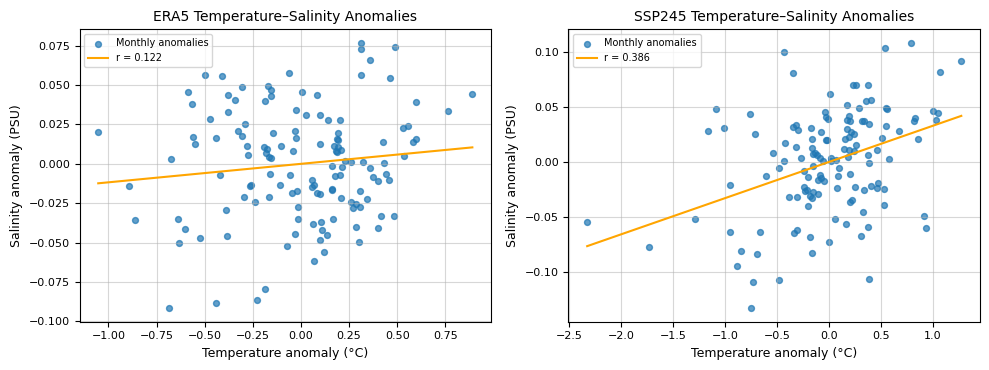

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# ---------------- ERA5 ----------------

era5_temp_anomaly_values = era5_temp_anomaly.values
era5_sal_anomaly_values = era5_sal_anomaly.values

a1, b1 = np.polyfit(
    era5_temp_anomaly_values,
    era5_sal_anomaly_values,
    1
)

era5_fit = a1 * era5_temp_anomaly_values + b1
era5_sort = np.argsort(era5_temp_anomaly_values)

axes[0].scatter(
    era5_temp_anomaly_values,
    era5_sal_anomaly_values,
    s=18,
    alpha=0.7,
    label="Monthly anomalies"
)

axes[0].plot(
    era5_temp_anomaly_values[era5_sort],
    era5_fit[era5_sort],
    color="orange",
    linewidth=1.5,
    label=f"r = {era5_anomaly_correlation.item():.3f}"
)

axes[0].set_title(
    "ERA5 Temperature–Salinity Anomalies",
    fontsize=10
)

axes[0].set_xlabel(
    "Temperature anomaly (°C)",
    fontsize=9
)

axes[0].set_ylabel(
    "Salinity anomaly (PSU)",
    fontsize=9
)

axes[0].tick_params(labelsize=8)

axes[0].legend(
    fontsize=7,
    loc="upper left"
)

axes[0].grid(True, alpha=0.5)


# ---------------- SSP245 ----------------

ssp245_temp_anomaly_values = ssp245_temp_anomaly.values
ssp245_sal_anomaly_values = ssp245_sal_anomaly.values

a2, b2 = np.polyfit(
    ssp245_temp_anomaly_values,
    ssp245_sal_anomaly_values,
    1
)

ssp245_fit = a2 * ssp245_temp_anomaly_values + b2
ssp245_sort = np.argsort(ssp245_temp_anomaly_values)

axes[1].scatter(
    ssp245_temp_anomaly_values,
    ssp245_sal_anomaly_values,
    s=18,
    alpha=0.7,
    label="Monthly anomalies"
)

axes[1].plot(
    ssp245_temp_anomaly_values[ssp245_sort],
    ssp245_fit[ssp245_sort],
    color="orange",
    linewidth=1.5,
    label=f"r = {ssp245_anomaly_correlation.item():.3f}"
)

axes[1].set_title(
    "SSP245 Temperature–Salinity Anomalies",
    fontsize=10
)

axes[1].set_xlabel(
    "Temperature anomaly (°C)",
    fontsize=9
)

axes[1].set_ylabel(
    "Salinity anomaly (PSU)",
    fontsize=9
)

axes[1].tick_params(labelsize=8)

axes[1].legend(
    fontsize=7,
    loc="upper left"
)

axes[1].grid(True, alpha=0.5)


plt.tight_layout()

plt.savefig(
    "temperature_salinity_anomaly_correlation_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Summary of Findings

- **Temperature:** SSP245 projects the mean annual cycle to be **2.6–4.3 °C warmer** than the ERA5 baseline in every month, with the largest increase in boreal spring/early summer (April–June) and the smallest in winter.
- **Salinity:** the projected change is **not uniform across the year** — winter months (Jan–Mar) show a slight *decrease* (down to −0.10 PSU) while summer months (Jul–Aug) show an *increase* (up to +0.33 PSU), meaning the seasonal salinity cycle amplifies under SSP245 rather than shifting in one direction.
- **Trends:** both variables show a positive linear trend over their respective 11-year windows in both the historical and projected periods (see Section 12–13 plots and the exported results table for exact per-variable slopes).
- **Temperature–salinity coupling:** the anomaly correlation is weak in the historical period (r = 0.122) but strengthens noticeably in the projected period (r = 0.386), suggesting the two variables become more tightly coupled under future warming.

Full numerical results (mean, standard deviation, min, max, annual trend) for both variables and both periods are exported to `statistics_table.xlsx`.